In [1]:
## Conditional Edges and Branching Logic with Gemini - LangGraph Demo
!pip install -q langgraph langchain-core google-generativeai

In [3]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph,END
from langchain_core.messages import HumanMessage, AIMessage
import google.generativeai as genai
import operator
from google.colab import userdata

In [5]:
try:
  GOOGLE_API_KEY = userdata.get('GEM_API_KEY')
  genai.configure(api_key=GOOGLE_API_KEY)
  print("API Key loaded and configured successfully")
except Exception as e:
  print(" Plese add GOOGLE_API_KEY to Colab Secrets")
  GOOGLE_API_KEY = None

Model_Name = 'gemini-2-0-flash-exp'
model = genai.GenerativeModel(Model_Name)

API Key loaded and configured successfully


In [13]:
def call_llm(prompt: str) -> str:
    try:
        response = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=0.3,
                max_output_tokens=500,
            ),
        )
        return response.text

    except Exception as e:
        raise Exception(f"LLM call failed: {str(e)}")




In [14]:
### part 1: Define the state

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    user_input:str
    query_type:str
    confidence:str
    processing_step:str
    result:str
    route_taken:str
    llm_reasoning:str

In [15]:
def input_node(state: AgentState) -> AgentState:
    """
    Node 1: Use Gemini LLM to classify the input intelligently
    """
    print(f" INPUT NODE: Received '{state['user_input']}'")
    print(f" Calling Gemini for classification...")

    # Create a classification prompt for the LLM
    classification_prompt = f"""Analyze this user input and classify it into ONE of these categories:
- GREETING: Social pleasantries, hellos, goodbyes
- QUESTION: Information requests, queries about facts or how-to
- COMMAND: Action requests, instructions to do something
- FEEDBACK: Opinions, complaints, praise, suggestions
- UNCLEAR: Ambiguous or off-topic inputs

User input: "{state['user_input']}"

Respond in this exact format:
CATEGORY: [category name]
CONFIDENCE: [number between 0.0 and 1.0]
REASONING: [brief explanation]"""

    try:
        # Call Gemini LLM using native SDK
        llm_output = call_llm(classification_prompt)

        # Parse LLM response
        lines = llm_output.strip().split('\n')
        category = "UNCLEAR"
        confidence = 0.5
        reasoning = "Unable to parse LLM response"

        for line in lines:
            if line.startswith("CATEGORY:"):
                category = line.split(":", 1)[1].strip().upper()
            elif line.startswith("CONFIDENCE:"):
                try:
                    confidence = float(line.split(":", 1)[1].strip())
                except:
                    confidence = 0.5
            elif line.startswith("REASONING:"):
                reasoning = line.split(":", 1)[1].strip()

        print(f"   ✓ Classification: {category} (confidence: {confidence:.2f})")
        print(f"   💭 Reasoning: {reasoning}")

        return {
            "messages": [HumanMessage(content=state["user_input"])],
            "query_type": category,
            "confidence": confidence,
            "llm_reasoning": reasoning,
            "processing_step": "classified"
        }

    except Exception as e:
        print(f"   ⚠️  Error in classification: {str(e)}")
        return {
            "messages": [HumanMessage(content=state["user_input"])],
            "query_type": "UNCLEAR",
            "confidence": 0.3,
            "llm_reasoning": f"Error: {str(e)}",
            "processing_step": "classification_failed"
        }

print("✓ LLM-powered classification node defined\n")


✓ LLM-powered classification node defined



In [16]:
def greeting_handler(state: AgentState) -> AgentState:
    """
    Handler for greetings - generates personalized responses
    """
    print(f" GREETING HANDLER: Generating warm response...")

    prompt = f"""Generate a friendly, warm greeting response to: "{state['user_input']}"
Keep it conversational and natural. 1-2 sentences maximum."""

    try:
        result = call_llm(prompt).strip()
        print(f"   ✓ Generated: {result[:60]}...")
    except Exception as e:
        result = "Hello! How can I help you today?"
        print(f"   ⚠️  Using fallback greeting")

    return {
        "messages": [AIMessage(content=result)],
        "result": result,
        "route_taken": "greeting_path",
        "processing_step": "greeting_completed"
    }

def question_handler(state: AgentState) -> AgentState:
    """
    Handler for questions - provides detailed answers
    """
    print(f"❓ QUESTION HANDLER: Researching answer...")

    prompt = f"""Answer this question thoroughly but concisely: "{state['user_input']}"

Provide a helpful, accurate response. Include examples if relevant. Keep it under 150 words."""

    try:
        result = call_llm(prompt).strip()
        print(f"   ✓ Generated answer ({len(result)} chars)")
    except Exception as e:
        result = f"I understand your question about: '{state['user_input']}'. Let me provide you with accurate information on this topic."
        print(f"   ⚠️  Using fallback response")

    return {
        "messages": [AIMessage(content=result)],
        "result": result,
        "route_taken": "question_path",
        "processing_step": "question_completed"
    }

def command_handler(state: AgentState) -> AgentState:
    """
    Handler for commands - acknowledges and plans action
    """
    print(f" COMMAND HANDLER: Processing action request...")

    prompt = f"""The user requested: "{state['user_input']}"

Acknowledge the request and outline the steps you would take to fulfill it. Be specific but concise (2-3 sentences)."""

    try:
        result = call_llm(prompt).strip()
        print(f"   ✓ Action plan generated")
    except Exception as e:
        result = f"I understand you want me to: '{state['user_input']}'. I'll process this request accordingly."
        print(f"   ⚠️  Using fallback response")

    return {
        "messages": [AIMessage(content=result)],
        "result": result,
        "route_taken": "command_path",
        "processing_step": "command_completed"
    }

def feedback_handler(state: AgentState) -> AgentState:
    """
    Handler for feedback - acknowledges and responds empathetically
    """
    print(f" FEEDBACK HANDLER: Processing feedback...")

    prompt = f"""The user provided feedback: "{state['user_input']}"

Respond empathetically, acknowledging their input. Thank them or address their concern appropriately. Keep it brief and sincere."""

    try:
        result = call_llm(prompt).strip()
        print(f"   ✓ Empathetic response generated")
    except Exception as e:
        result = "Thank you for your feedback! I really appreciate you taking the time to share your thoughts."
        print(f"   ⚠️  Using fallback response")

    return {
        "messages": [AIMessage(content=result)],
        "result": result,
        "route_taken": "feedback_path",
        "processing_step": "feedback_completed"
    }

def fallback_handler(state: AgentState) -> AgentState:
    """
    Fallback handler for unclear inputs - asks for clarification
    """
    print(f" FALLBACK HANDLER: Input unclear, requesting clarification...")

    prompt = f"""The user said: "{state['user_input']}" but it's unclear what they want.

Politely ask for clarification. Be helpful and suggest what kind of information you can provide. Keep it brief."""

    try:
        result = call_llm(prompt).strip()
        print(f"   ✓ Clarification request generated")
    except Exception as e:
        result = "I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?"
        print(f"   ⚠️  Using fallback clarification")

    return {
        "messages": [AIMessage(content=result)],
        "result": result,
        "route_taken": "fallback_path",
        "processing_step": "fallback_completed"
    }

def output_node(state: AgentState) -> AgentState:
    """
    Final node: Package the response
    """
    print(f" OUTPUT NODE: Finalizing response from {state['route_taken']}...")

    return {
        "messages": [AIMessage(content=f"[{state['route_taken']}] {state['result']}")],
        "processing_step": "completed"
    }

print("✓ All handler nodes defined with LLM integration\n")

✓ All handler nodes defined with LLM integration



In [17]:
def route_query(state: AgentState) -> Literal["greeting", "question", "command", "feedback", "fallback"]:
    """
    Router function based on LLM classification
    """

    print(f" ROUTER: Deciding route for query_type='{state['query_type']}', confidence={state['confidence']:.2f}")

    query_type = state["query_type"]
    confidence = state["confidence"]

    # Route based on LLM classification and confidence
    if confidence < 0.6:
        print(f"   → Low confidence, routing to FALLBACK")
        return "fallback"

    if query_type == "GREETING":
        print(f"   → Routing to GREETING handler")
        return "greeting"
    elif query_type == "QUESTION":
        print(f"   → Routing to QUESTION handler")
        return "question"
    elif query_type == "COMMAND":
        print(f"   → Routing to COMMAND handler")
        return "command"
    elif query_type == "FEEDBACK":
        print(f"   → Routing to FEEDBACK handler")
        return "feedback"
    else:
        print(f"   → Unknown category, routing to FALLBACK")
        return "fallback"

print("✓ Router function defined with confidence thresholding\n")

✓ Router function defined with confidence thresholding



In [18]:
workflow = StateGraph(AgentState)

# Add all nodes
workflow.add_node("input", input_node)
workflow.add_node("greeting", greeting_handler)
workflow.add_node("question", question_handler)
workflow.add_node("command", command_handler)
workflow.add_node("feedback", feedback_handler)
workflow.add_node("fallback", fallback_handler)
workflow.add_node("output", output_node)

print("✓ All nodes added to graph\n")

# Set entry point
workflow.set_entry_point("input")

# Add conditional edge with 5 possible routes
workflow.add_conditional_edges(
    "input",
    route_query,
    {
        "greeting": "greeting",
        "question": "question",
        "command": "command",
        "feedback": "feedback",
        "fallback": "fallback"
    }
)

print("✓ CONDITIONAL EDGE added with 5 routes!\n")

# Add edges to output
workflow.add_edge("greeting", "output")
workflow.add_edge("question", "output")
workflow.add_edge("command", "output")
workflow.add_edge("feedback", "output")
workflow.add_edge("fallback", "output")
workflow.add_edge("output", END)

print("✓ All edges connected (handlers → output → END)\n")

✓ All nodes added to graph

✓ CONDITIONAL EDGE added with 5 routes!

✓ All edges connected (handlers → output → END)



In [19]:
app = workflow.compile()

print("✓ Graph compiled with LLM-powered routing!\n")
print("=" * 70)

✓ Graph compiled with LLM-powered routing!



In [21]:
def run_workflow(user_input: str):
    """
    Helper function to run the workflow
    """
    print(f"\n{'=' * 70}")
    print(f"RUNNING WORKFLOW: '{user_input}'")
    print(f"{'=' * 70}")

    initial_state = {
        "messages": [],
        "user_input": user_input,
        "query_type": "",
        "confidence": 0.0,
        "processing_step": "initialized",
        "result": "",
        "route_taken": "",
        "llm_reasoning": ""
    }

    final_state = app.invoke(initial_state)

    print(f"\n{'=' * 70}")
    print(f"WORKFLOW COMPLETED")
    print(f"{'=' * 70}")
    print(f" Results:")
    print(f"  - Query Type: {final_state['query_type']}")
    print(f"  - Confidence: {final_state['confidence']:.2f}")
    print(f"  - Route Taken: {final_state['route_taken']}")
    print(f"  - LLM Reasoning: {final_state['llm_reasoning']}")
    print(f"\n Final Response:")
    print(f"  {final_state['result']}")
    print(f"{'=' * 70}")

    return final_state

In [23]:
print("\n" + "=" * 70)
print("DEMO: Testing LLM-Powered Conditional Routing")
print("=" * 70)

# Test 1: Simple greeting
print("\n Test 1: Simple Greeting")
run_workflow("Hey there! How's it going?")

# Test 2: Technical question
print("\n Test 2: Technical Question")
run_workflow("What is LangGraph and how does it differ from LangChain?")

# Test 3: Action command
print("\n Test 3: Action Command")
run_workflow("Can you create a summary of the latest AI research papers?")

# Test 4: User feedback
print("\n Test 4: User Feedback")
run_workflow("This tool is amazing! The responses are really helpful.")

# Test 5: Complex question
print("\n Test 5: Complex Question")
run_workflow("How do conditional edges improve workflow efficiency compared to linear flows?")

# Test 6: Ambiguous input
print("\n Test 6: Ambiguous Input")
run_workflow("hmm...I see ")

# Test 7: Multi-intent input (tests LLM classification)
print("\n Test 7: Mixed Intent")
run_workflow("Hi! Can you explain how neural networks work?")


DEMO: Testing LLM-Powered Conditional Routing

 Test 1: Simple Greeting

RUNNING WORKFLOW: 'Hey there! How's it going?'
 INPUT NODE: Received 'Hey there! How's it going?'
 Calling Gemini for classification...


   ⚠️  Error in classification: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
 ROUTER: Deciding route for query_type='UNCLEAR', confidence=0.30
   → Low confidence, routing to FALLBACK
 FALLBACK HANDLER: Input unclear, requesting clarification...


   ⚠️  Using fallback clarification
 OUTPUT NODE: Finalizing response from fallback_path...

WORKFLOW COMPLETED
 Results:
  - Query Type: UNCLEAR
  - Confidence: 0.30
  - Route Taken: fallback_path
  - LLM Reasoning: Error: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

 Final Response:
  I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?

 Test 2: Technical Question

RUNNING WORKFLOW: 'What is LangGraph and how does it differ from LangChain?'
 INPUT NODE: Received 'What is LangGraph and how does it differ from LangChain?'
 Calling Gemini for classification...


   ⚠️  Error in classification: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
 ROUTER: Deciding route for query_type='UNCLEAR', confidence=0.30
   → Low confidence, routing to FALLBACK
 FALLBACK HANDLER: Input unclear, requesting clarification...


   ⚠️  Using fallback clarification
 OUTPUT NODE: Finalizing response from fallback_path...

WORKFLOW COMPLETED
 Results:
  - Query Type: UNCLEAR
  - Confidence: 0.30
  - Route Taken: fallback_path
  - LLM Reasoning: Error: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

 Final Response:
  I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?

 Test 3: Action Command

RUNNING WORKFLOW: 'Can you create a summary of the latest AI research papers?'
 INPUT NODE: Received 'Can you create a summary of the latest AI research papers?'
 Calling Gemini for classification...


...

   ⚠️  Error in classification: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
 ROUTER: Deciding route for query_type='UNCLEAR', confidence=0.30
   → Low confidence, routing to FALLBACK
 FALLBACK HANDLER: Input unclear, requesting clarification...


   ⚠️  Using fallback clarification
 OUTPUT NODE: Finalizing response from fallback_path...

WORKFLOW COMPLETED
 Results:
  - Query Type: UNCLEAR
  - Confidence: 0.30
  - Route Taken: fallback_path
  - LLM Reasoning: Error: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

 Final Response:
  I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?

 Test 7: Mixed Intent

RUNNING WORKFLOW: 'Hi! Can you explain how neural networks work?'
 INPUT NODE: Received 'Hi! Can you explain how neural networks work?'
 Calling Gemini for classification...


   ⚠️  Error in classification: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
 ROUTER: Deciding route for query_type='UNCLEAR', confidence=0.30
   → Low confidence, routing to FALLBACK
 FALLBACK HANDLER: Input unclear, requesting clarification...


   ⚠️  Using fallback clarification
 OUTPUT NODE: Finalizing response from fallback_path...

WORKFLOW COMPLETED
 Results:
  - Query Type: UNCLEAR
  - Confidence: 0.30
  - Route Taken: fallback_path
  - LLM Reasoning: Error: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2-0-flash-exp is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

 Final Response:
  I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?


{'messages': [HumanMessage(content='Hi! Can you explain how neural networks work?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?", additional_kwargs={}, response_metadata={}),
  AIMessage(content="[fallback_path] I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?", additional_kwargs={}, response_metadata={})],
 'user_input': 'Hi! Can you explain how neural networks work?',
 'query_type': 'UNCLEAR',
 'confidence': 0.3,
 'processing_step': 'completed',
 'result': "I want to help you, but I'm not quite sure what you're looking for. Could you please provide more details or rephrase your request?",
 'route_taken': 'fallback_path',
 'llm_reasoning': 'Error: LLM call failed: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2-0-flash-exp:gen

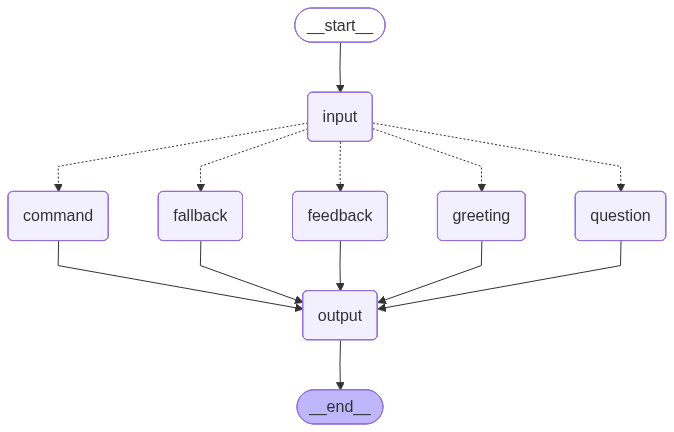

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))